# One - One

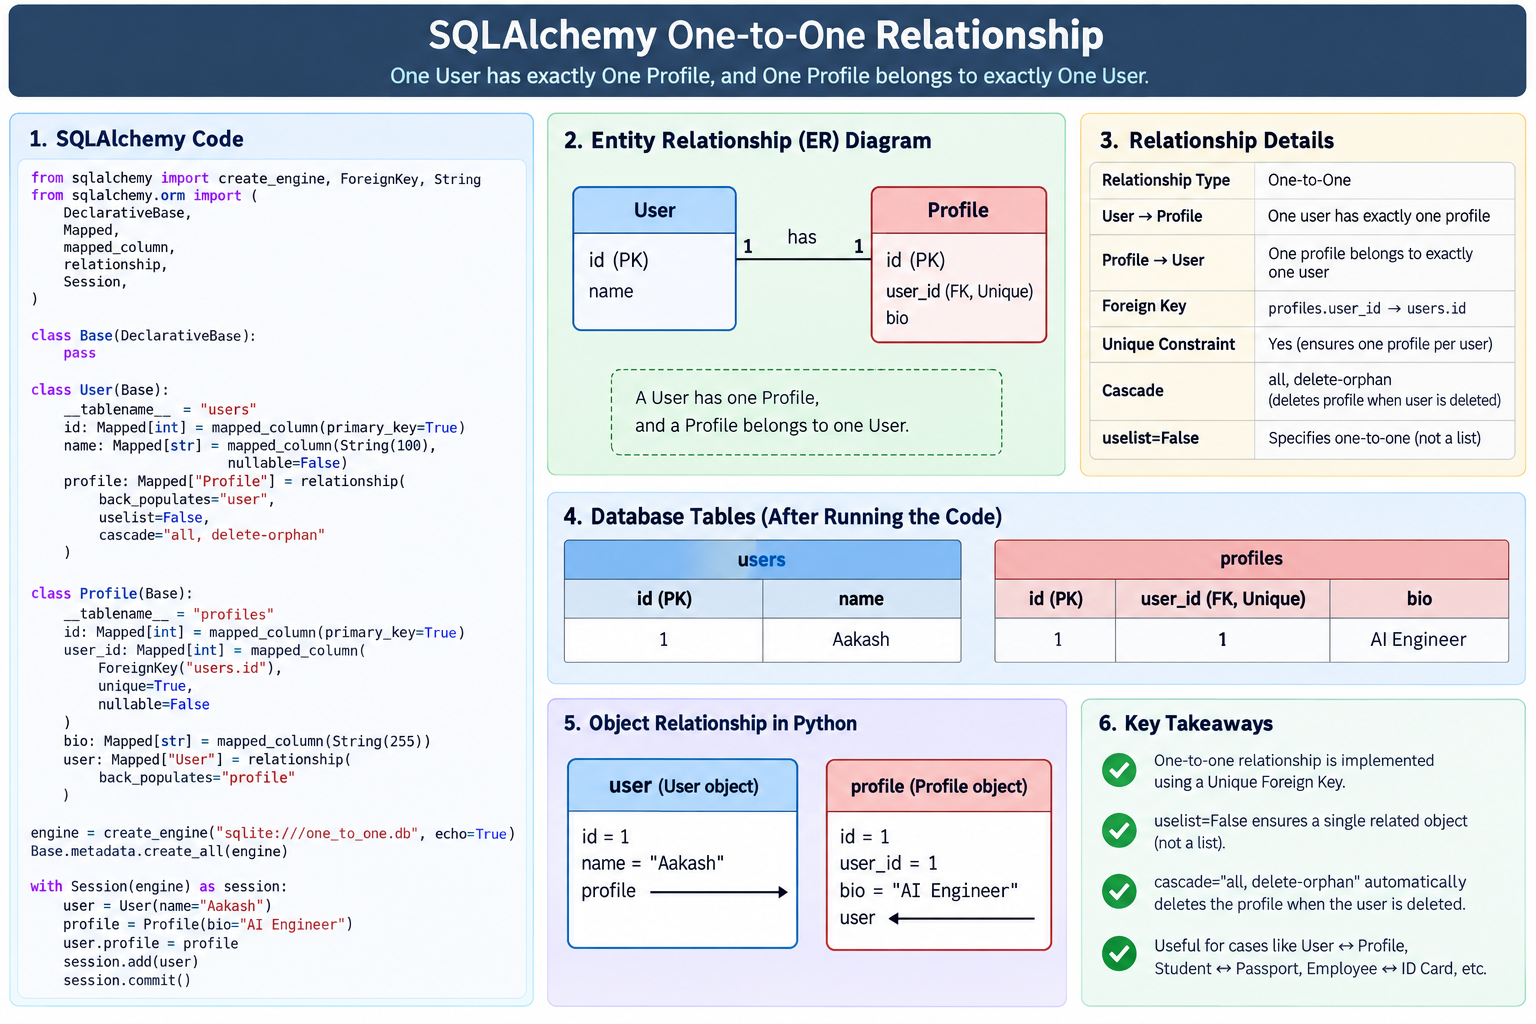

In [ ]:
from sqlalchemy import create_engine , ForeignKey , String 
from sqlalchemy.orm import DeclarativeBase , Mapped , mapped_column , relationship , Session 

class Base(DeclarativeBase):
    pass

class User(Base):
    __tablename__="users"

    id:Mapped[int]=mapped_column(primary_key=True)

    name:Mapped[str]=mapped_column(nullable=False)

    profile:Mapped["Profile"]=relationship(back_populates="user", uselist=False , cascade="all , delete-orphan")


class Profile(Base):
    __tablename__="profiles"

    id:Mapped[int]=mapped_column(primary_key=True)

    user_id:Mapped[int]=mapped_column(ForeignKey("users.id") , unique= True , nullable=False)
    bio: Mapped[str] = mapped_column(String(255))

    user:Mapped["User"]=relationship(back_populates="profile")


engine=create_engine("sqlite:///one_to_one.db" , echo=True)
Base.metadata.create_all(engine)

with Session(engine) as session:
    user=User(name="Aakash")
    profile=Profile(bio="Ai Engineer")

    user.profile=profile
    session.add(user)
    session.commit()

2026-09-12 21:37:43,180 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-09-12 21:37:43,180 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("users")
2026-09-12 21:37:43,180 INFO sqlalchemy.engine.Engine [raw sql] ()
2026-09-12 21:37:43,181 INFO sqlalchemy.engine.Engine PRAGMA temp.table_info("users")
2026-09-12 21:37:43,181 INFO sqlalchemy.engine.Engine [raw sql] ()
2026-09-12 21:37:43,182 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("profiles")
2026-09-12 21:37:43,182 INFO sqlalchemy.engine.Engine [raw sql] ()
2026-09-12 21:37:43,183 INFO sqlalchemy.engine.Engine PRAGMA temp.table_info("profiles")
2026-09-12 21:37:43,184 INFO sqlalchemy.engine.Engine [raw sql] ()
2026-09-12 21:37:43,184 INFO sqlalchemy.engine.Engine 
CREATE TABLE users (
	id INTEGER NOT NULL, 
	name VARCHAR NOT NULL, 
	PRIMARY KEY (id)
)


2026-09-12 21:37:43,184 INFO sqlalchemy.engine.Engine [no key 0.00039s] ()
2026-09-12 21:37:43,194 INFO sqlalchemy.engine.Engine 
CREATE TABLE profiles (
	id INTEGER

In [ ]:
with Session(engine) as session:

    user = session.get(User, 1)

    print(user.name)
    print(user.profile.bio)

2026-09-12 21:50:35,973 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-09-12 21:50:35,974 INFO sqlalchemy.engine.Engine SELECT users.id AS users_id, users.name AS users_name 
FROM users 
WHERE users.id = ?
2026-09-12 21:50:35,975 INFO sqlalchemy.engine.Engine [cached since 10.12s ago] (1,)
Aakash
2026-09-12 21:50:35,977 INFO sqlalchemy.engine.Engine SELECT profiles.id AS profiles_id, profiles.user_id AS profiles_user_id, profiles.bio AS profiles_bio 
FROM profiles 
WHERE ? = profiles.user_id
2026-09-12 21:50:35,977 INFO sqlalchemy.engine.Engine [cached since 10.12s ago] (1,)
Ai Engineer
2026-09-12 21:50:35,978 INFO sqlalchemy.engine.Engine ROLLBACK


# One - To - Many 

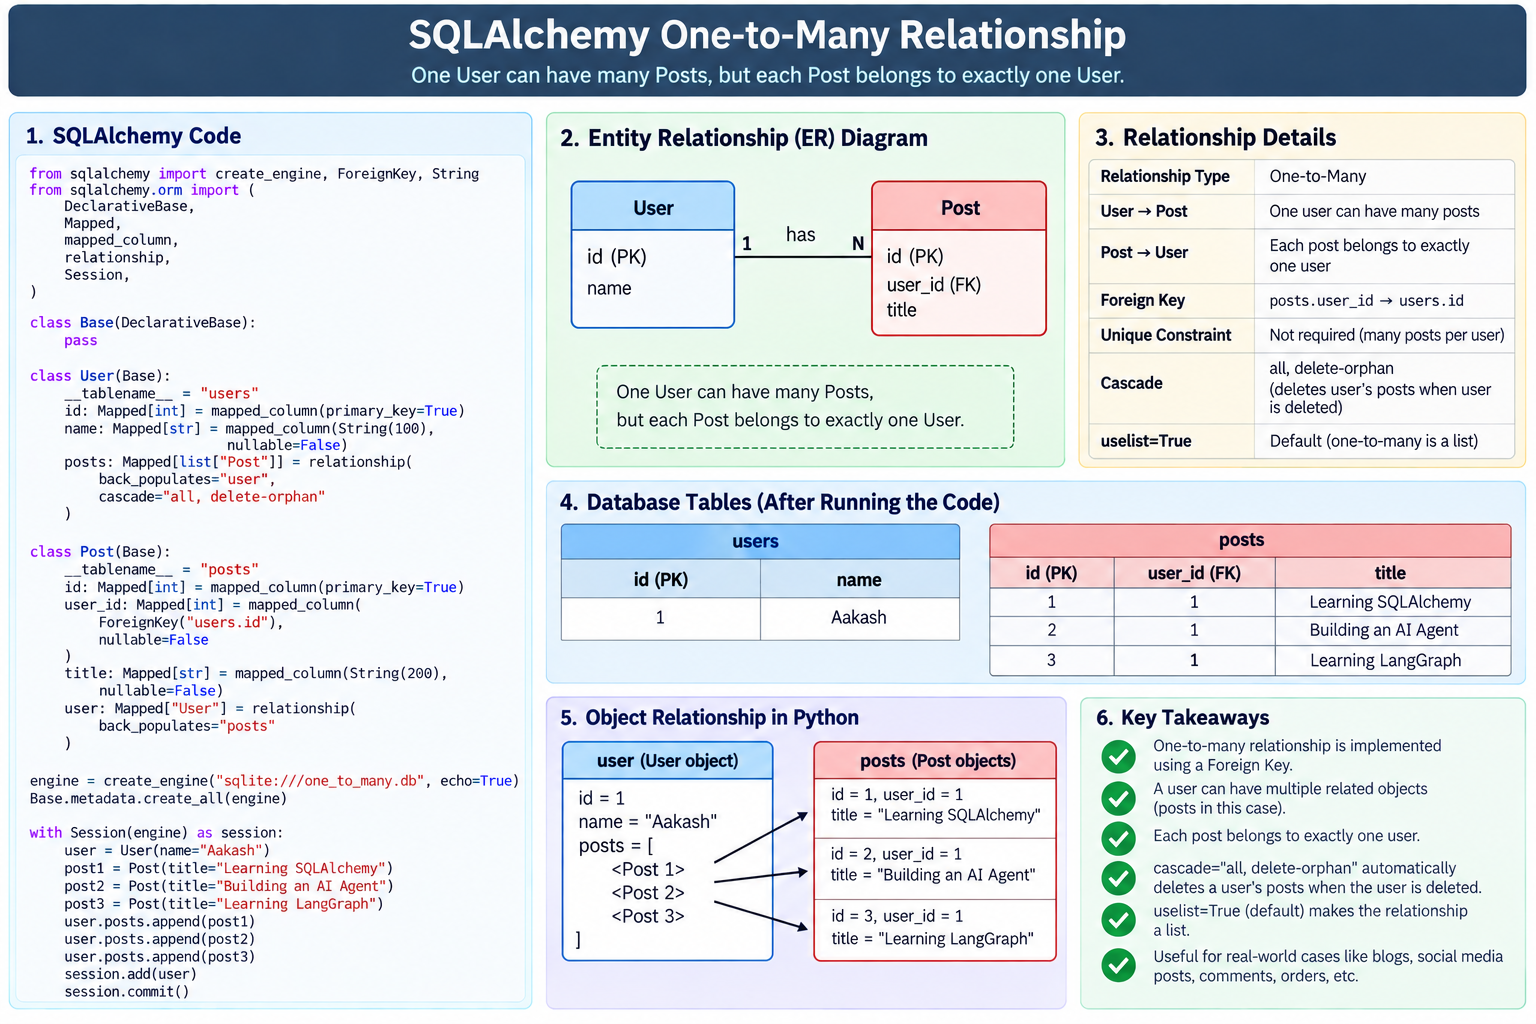

In [1]:
from sqlalchemy import create_engine , ForeignKey
from sqlalchemy.orm import relationship , mapped_column , DeclarativeBase , Mapped , Session

class Base(DeclarativeBase):
    pass

class User(Base):

    __tablename__="users"

    id:Mapped[int]=mapped_column(primary_key=True)

    name:Mapped[str]=mapped_column(nullable=False)

    posts:Mapped[list["Post"]]=relationship(back_populates="user", cascade="all , delete-orphan")


class Post(Base):

    __tablename__="posts"

    id:Mapped[int]=mapped_column(primary_key=True)

    user_id:Mapped[int]=mapped_column(ForeignKey("users.id"), nullable=False)

    title:Mapped[str]=mapped_column(nullable=False)

    user:Mapped["User"]=relationship(back_populates="posts")


engine=create_engine("sqlite:///one-to-many.db" , echo= False)

Base.metadata.create_all(engine)

with Session(engine) as session:

    user=User(name="Aakash")

    post1=Post(title="Learning SQLALCHEMY")

    post2=Post(title="Building an Ai agent")

    post3=Post(title="Learning Langgraph")

    user.posts.append(post1)
    user.posts.append(post2)
    user.posts.append(post3)

    session.add(user)
    session.commit()
    

In [2]:
with Session(engine) as session:

    user = session.get(User, 1)

    print(user.name)

    for post in user.posts:
        print(post.title)

Aakash
Learning SQLALCHEMY
Building an Ai agent
Learning Langgraph


# MANY-TO-MANY

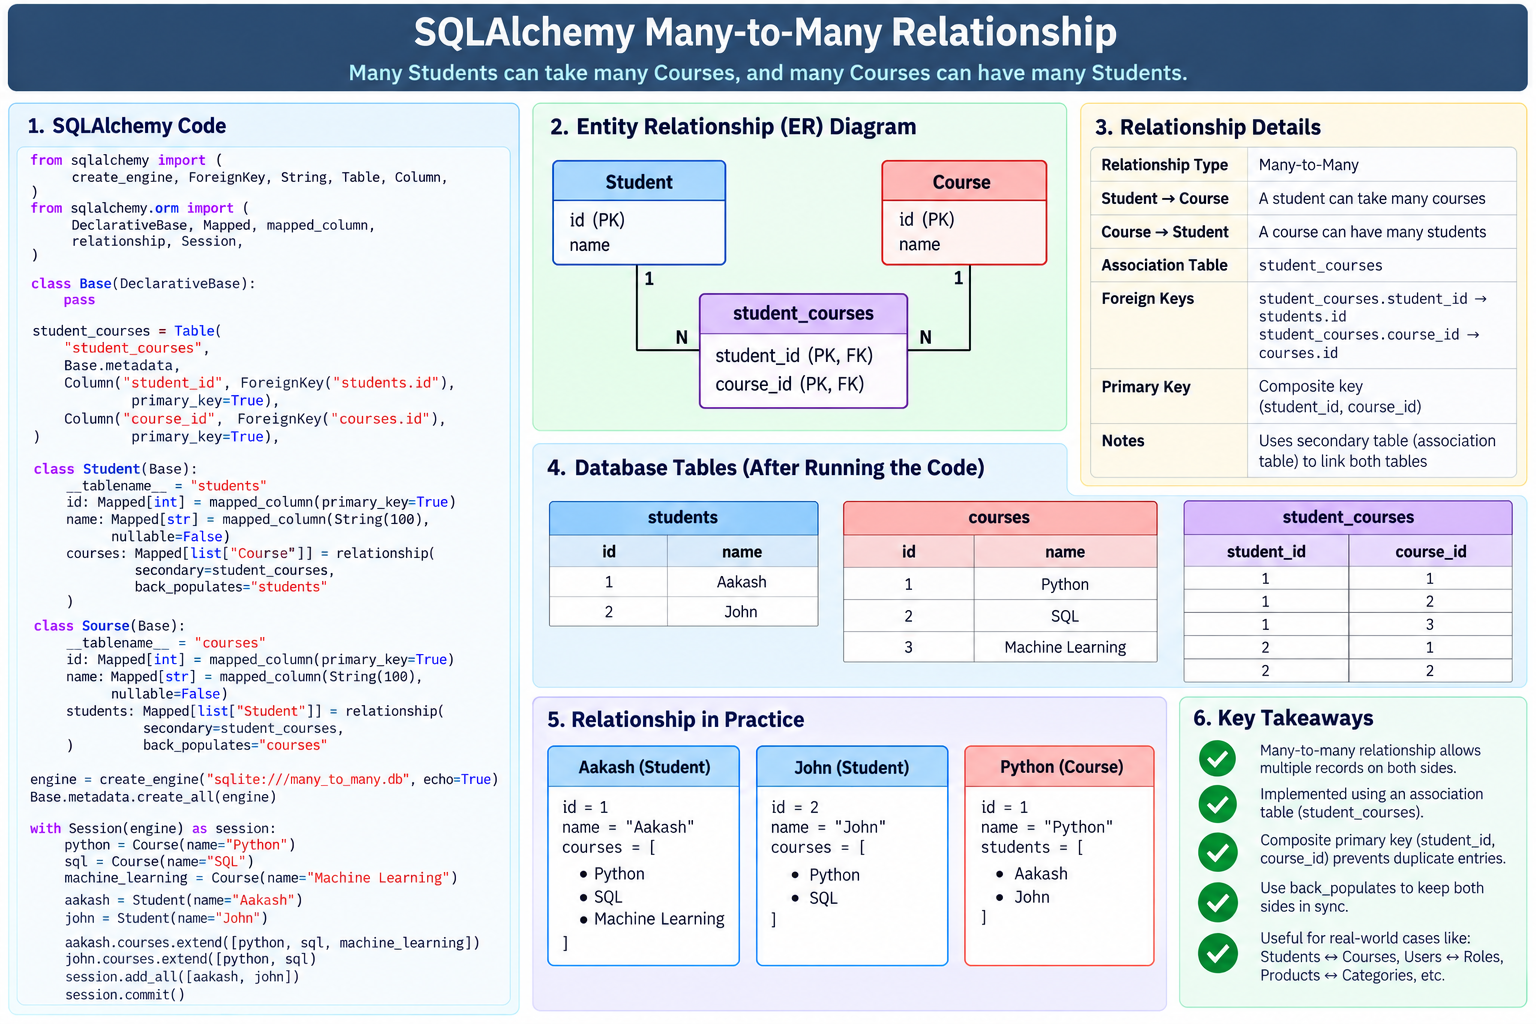

In [3]:
from sqlalchemy import create_engine , ForeignKey , String , Table , Column 
from sqlalchemy.orm import DeclarativeBase , Mapped , mapped_column , relationship , Session 

class Base(DeclarativeBase):
    pass

student_courses=Table(
    "student_courses",Base.metadata,
    Column("student_id", ForeignKey("students.id") , primary_key=True),

    Column("course_id" , ForeignKey("courses.id") , primary_key=True),

)

class Student(Base):
    __tablename__="students"

    id:Mapped[int]=mapped_column(primary_key=True)

    name:Mapped[str]=mapped_column(nullable=False)

    courses:Mapped[list["Course"]]=relationship(secondary=student_courses , back_populates="students")

class Course(Base):
    __tablename__="courses"

    id:Mapped[int]=mapped_column(primary_key=True)

    name:Mapped[str]=mapped_column(nullable=False)

    students:Mapped[list["Student"]]=relationship(secondary=student_courses , back_populates="courses")


engine=create_engine("sqlite:///many-to-many.db" , echo=False)

Base.metadata.create_all(engine)

with Session(engine) as session:
    python=Course(name="Python")
    sql=Course(name="sql")
    machine_learning=Course(name="machine_learning")

    stud1=Student(name="Aakash")
    stud2=Student(name="Tyler")

    stud1.courses.append(python)
    stud1.courses.append(sql)
    stud1.courses.append(machine_learning)

    stud2.courses.append(python)
    stud2.courses.append(sql)


    session.add_all([stud1 , stud2])
    session.commit()

In [4]:
with Session(engine) as session :
    student=session.get(Student ,1)
    print(student.name)

    for course in student.courses:
        print(course.name)

Aakash
Python
sql
machine_learning
